In [76]:
import random
import math
import matplotlib.pyplot as plt


In [77]:
class Node(object):
    def __init__(self,data,level = 0):
        self.data = data
        self.next = [None] * (level)
    def __str__(self):
        return "Node(%s,%s)" % (self.data,len(self.next))
    __repr__ = __str__

In [78]:
class SkipList(object):
    def __init__(self, max_level=8):
        self.max_level = max_level
        n = Node(None,max_level)
        self.head = n
        self.verbose = False
    '''
    def randomLevel(self, max_level):
        num = random.randint(1,2**max_level-1)
        lognum = math.log(num,2)
        level = int(math.floor(lognum))
        return max_level - level
    '''
    def randomLevel(self,max_level):
        level = 1
        while random.random() < 0.5 and level < max_level:
            level += 1
        return level
    def updateList(self, data):
        update = [None] * (self.max_level)
        n = self.head
        self._n_traverse = 0
        level = self.max_level - 1
        while level >= 0:
            if self.verbose and n.next[level] != None and n.next[level].data >= data:
                print(f'DROP down from level {level + 1}')
            while n.next[level] != None and n.next[level].data < data:
                n = n.next[level]
                self._n_traverse += 1
                if self.verbose:
                    print(f'AT level {level} data {n.next[level].data}')
            update[level] = n
            level -= 1
        return update
    def insert_node(self, data, level=None):
        if level is None:
            level = self.randomLevel(self.max_level)
        node = Node(data,level)
        update = self.updateList(data)
        if self.find(data, update) == None:
            for i in range(level):
                node.next[i] = update[i].next[i]
                update[i].next[i] = node
    def find(self, data, update=None):
        if update is None:
            update = self.updateList(data)
        if len(update) > 0:
            n = update[0].next[0]
            if n != None and n.data == data:
                return n
        return None
    def printLevel(sl,level):

        n = sl.head.next[level]
        if n == None:
            return
        print(f'Level {level}', end='::')
        while n != None:
            print(f' {n.data} =>', end='')
            n = n.next[level]
        print("END")




In [79]:
def experiment():
    sizes = [1000, 2000, 5000, 10000, 20000]
    avg_costs = []

    for n in sizes:
        sl = SkipList(max_level=25)

        # random input
        values = random.sample(range(n * 10), n)

        # insert values
        for v in values:
            sl.insert_node(v)

        # random searches
        searches = random.sample(values, min(500, n))
        total_cost = 0

        for s in searches:
            sl.updateList(s)
            total_cost += sl._n_traverse

        avg_costs.append(total_cost / len(searches))

    # plot
    plt.figure()
    plt.plot(sizes, avg_costs, marker='o')
    plt.xlabel("Number of elements (n)")
    plt.ylabel("Average number of levels searched")
    plt.title("Skip List Search Cost vs Input Size")
    plt.show()

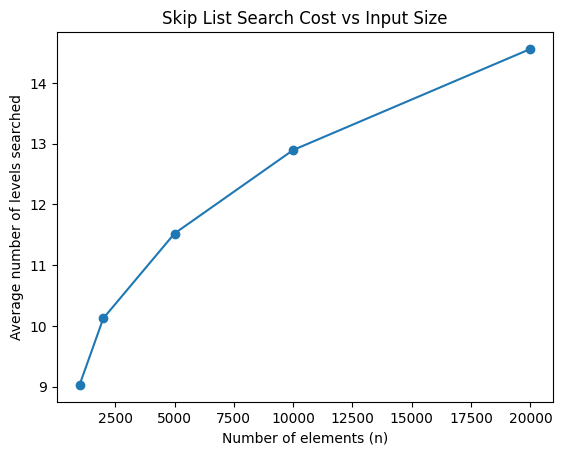

In [82]:
if __name__ == "__main__":
    # Implementation of Skiplist
    '''
    sl = SkipList(100)
    for i in range(0, 100000, 2):
        sl.insert_node(i)

    for lvl in range(100):
        sl.printLevel(lvl)
    '''
    experiment()